# HW 4 - Statistics Module 1
## BIOMEDE 241, Winter 2026
Please pay careful attention to how the answer should be displayed in the code (for example as a number or a plot), as the graders will run your code and primarily check the output.

All of the libraries have been included for you with the following header:


In [1]:
import statistics as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import scipy

np.random.seed(42)

%matplotlib inline

# Problem 1: Mean, Variance, Standard Deviation, Percentiles
For this exercise, your dataset is a list of heights (in inches) for a group of people, and you will calculate statistics of those data.<br> **Make sure to include comments or other documentation in all your functions!**




> a. Write a function to calculate the mean of a list of data using the 'sum' and 'len' commands only. Use an assert command inside this function to verify the answer using the appropriate numpy library. Return the mean and print the answer for the heights dataset.



In [ ]:
# Store the dataset of heights into a list
heights = [60.3, 62.7, 65.9, 61.4, 70.9, 68., 61.8, 72.5, 65.5, 71.3, 73.6,
       70.6, 75.7, 65.8, 66.6, 65.6, 67.1, 68.4, 70.3, 64.2, 74.5,
       72.3, 62.3, 77.4, 79.5, 75.9, 69.1, 64.6, 75.3, 78]

def mymean(x):
       """
       Calculate the mean of a list using only sum and len.
       Also verify the result using numpy.
       """
       mean_val = sum(x) / len(x)
       assert np.isclose(mean_val, np.mean(x)), "Mean does not match numpy mean."
       return mean_val

print("Mean:", mymean(heights))

Mean: 69.23666666666666


> b.	Now do the same thing with variance. Write a function to calculate it with only the 'sum' and 'len' commands, and use an assert command to verify the answer with the numpy library, and once with only 'sum' and 'len' commands. Note that the ‘N’ in denominator is ‘N-1’.



In [3]:
def myvar(x):
    """
    Calculate the sample variance of a list using only sum and len.
    Uses N-1 in the denominator.
    Also verify the result using numpy.
    """
    mean_val = mymean(x)
    var_val = sum((xi - mean_val)**2 for xi in x) / (len(x) - 1)
    assert np.isclose(var_val, np.var(x, ddof=1)), "Variance does not match numpy variance."
    return var_val

print("Variance:", myvar(heights))

Variance: 29.19619540229886


> c. Write a function to use Numpy's ‘std’ to calculate the standard deviation and use an assert command to verify that squaring it gives you the variance by calling your variance function. You can square things using '**'.


In [4]:
def mystd(x):
    """
    Calculate the sample standard deviation using numpy std.
    Verify that squaring the standard deviation gives the variance.
    """
    std_val = np.std(x, ddof=1)
    assert np.isclose(std_val**2, myvar(x)), "Squared standard deviation does not match variance."
    return std_val

print("Standard deviation:", mystd(heights))

Standard deviation: 5.403350386778453


> d. Calculate how many data points you would expect to be within one standard deviation of the mean. Then count how many of the data points are within one standard deviation of the mean. Display both numbers.


In [5]:
# Expected number within one standard deviation of the mean
expected_within_1std = 0.68 * len(heights)

# Actual number within one standard deviation of the mean
mean_val = mymean(heights)
std_val = mystd(heights)
actual_within_1std = sum(1 for h in heights if mean_val - std_val <= h <= mean_val + std_val)

print("Expected number within 1 standard deviation:", expected_within_1std)
print("Actual number within 1 standard deviation:", actual_within_1std)

Expected number within 1 standard deviation: 20.400000000000002
Actual number within 1 standard deviation: 19


> e.	Plot a histogram of this data using the ‘plt.hist’ and 'plt.show' commands with exactly 8 bins.

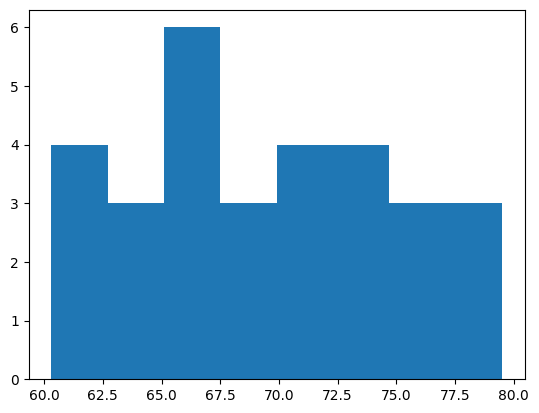

In [6]:
plt.hist(heights, bins=8)
plt.show()

> f.	Write a script to calculate the 25th-50th 75th percentiles using the equation from class. Do this in a ‘for’ statement, i.e. ‘for p = [0.25 0.5 0.75]’. The 'sort' command will be helpful.

In [7]:
# Calculate the 25th, 50th, and 75th percentiles using the class equation
sorted_heights = sorted(heights)
n = len(sorted_heights)

for p in [0.25, 0.5, 0.75]:
    idx = (n - 1) * p
    lower = math.floor(idx)
    upper = math.ceil(idx)

    if lower == upper:
        percentile = sorted_heights[int(idx)]
    else:
        frac = idx - lower
        percentile = sorted_heights[lower] + frac * (sorted_heights[upper] - sorted_heights[lower])

    print(f"{int(p*100)}th percentile:", percentile)

25th percentile: 65.525
50th percentile: 68.75
75th percentile: 73.32499999999999


> g. Plot as a box and whiskers plot using ‘plt.boxplot’ and check your answers from f.

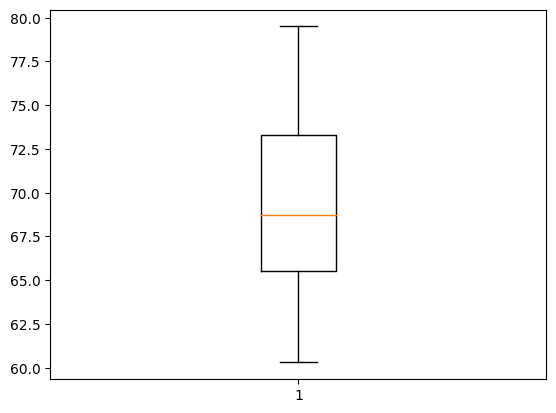

In [8]:
plt.boxplot(heights)
plt.show()

# Problem 2: Bernoulli Distribution

> a. Figure out how to generate bernoulli distributed random values by searching for the correct command from the scipy.stats. You will need to use the 'from ____ import ____' notation. Then simulate 1000 “draws” from a Bernoulli variable for p=0.3 and p = 0.6. Create two arrays of 1000 values named ‘data1’ and ‘data2’.  Then, take the mean and variance of this data using the mean and var commands from scipy or numpy.


In [9]:
from scipy.stats import bernoulli

# Generate 1000 draws for each Bernoulli distribution
data1 = bernoulli.rvs(p=0.3, size=1000)
data2 = bernoulli.rvs(p=0.6, size=1000)

# Compute sample mean and variance
print("data1 mean:", np.mean(data1))
print("data1 variance:", np.var(data1))

print("data2 mean:", np.mean(data2))
print("data2 variance:", np.var(data2))

data1 mean: 0.288
data1 variance: 0.20505599999999993
data2 mean: 0.57
data2 variance: 0.24509999999999996


> b. Verify that your answers match what would be predicted from the mean and variance of this distribution we learned in class for Bernoulli random variables in terms of 'n' and ‘p’. Use a print command to print the naswers in the same way above, but don't use any mean or variance functions.
Do these numbers match from earlier? Does it make sense?

In [10]:
# Predicted mean and variance without using mean/var functions
p1 = 0.3
p2 = 0.6

print("Predicted data1 mean:", p1)
print("Predicted data1 variance:", p1 * (1 - p1))

print("Predicted data2 mean:", p2)
print("Predicted data2 variance:", p2 * (1 - p2))

Predicted data1 mean: 0.3
Predicted data1 variance: 0.21
Predicted data2 mean: 0.6
Predicted data2 variance: 0.24


Yes, the sample mean and variance closely match the theoretical Bernoulli values $E[X]=p$ and $Var(X)=p(1-p)$, which is expected with 1000 draws.

c. Now let's think about conditional probability. These two distributions above were generated completely independently. So knowing what came from one of the distributions shouldn't tell you anything about the other. Check that this is true. Within the 1000 draws, count up what proportion of data2 came up as a '1' whenever data1 was a '1'. I.e. of the times data2 was a one, what proportion of those times was data1 also one. Does the proportion make sense?

In [11]:
# Proportion of times data2 is 1 given that data1 is 1
mask1 = (data1 == 1)
prop = np.sum(data2[mask1] == 1) / np.sum(mask1)

print("P(data2 = 1 | data1 = 1):", prop)

P(data2 = 1 | data1 = 1): 0.5347222222222222


Yes, the proportion is close to 0.6, which makes sense because data1 and data2 were generated independently so $P(data2=1|data1=1)=P(data2=1)=0.6$.

d. Now let's make a dataset that is not independent of these datasets. Make third dataset, data3 with 1000 values based on the values in data1. Specifically, every time data1 came up as a '1', flip a fair coin with p=0.5 to generate a value for data3. For all instances where data1 is 0, data3 should also be zero. Count up the times that data3 is a '1'. On the slide with Bayes rule, use the definition of conditional probability to see what you would predict the probability of getting both 1s should be.

In [12]:
# Create data3 based on data1
data3 = np.zeros(1000, dtype=int)

# Where data1 == 1, flip a fair coin
mask1 = (data1 == 1)
data3[mask1] = bernoulli.rvs(p=0.5, size=np.sum(mask1))

# Count how many times data3 is 1
print("Number of times data3 = 1:", np.sum(data3 == 1))

# Count how many times both data1 and data3 are 1
both_ones = np.sum((data1 == 1) & (data3 == 1))
print("Number of times both data1 and data3 are 1:", both_ones)

# Predicted probability of both being 1
predicted_prob_both = 0.3 * 0.5
print("Predicted P(data1 = 1 and data3 = 1):", predicted_prob_both)

# Sample proportion of both being 1
print("Observed proportion of both being 1:", both_ones / 1000)

Number of times data3 = 1: 152
Number of times both data1 and data3 are 1: 152
Predicted P(data1 = 1 and data3 = 1): 0.15
Observed proportion of both being 1: 0.152


Using conditional probability, $P(data1=1 \text{ and } data3=1)=P(data3=1|data1=1)P(data1=1)=0.5\times0.3=0.15$, which should match the observed proportion.

# Problem 3: Binomial Distribution

> a. Search online for the syntax of the 'random' command in the numpy library to figure out how to general random data from a binomial distribution. Then generate 1,000,000 draws from a binomial distribution with n=16 and p=0.6. Plot a histogram of this data with 16 bins. Include axis labels.


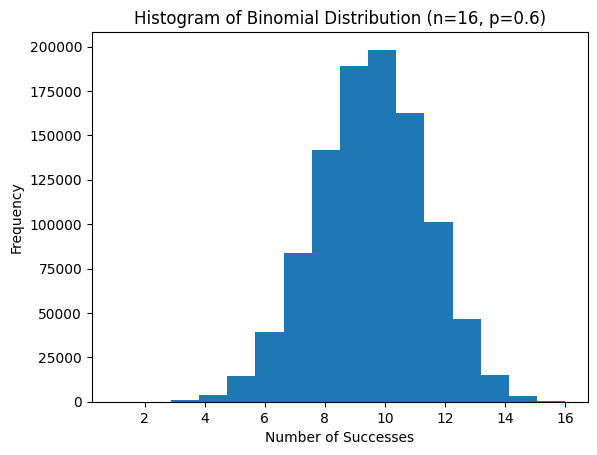

In [14]:
from numpy import random

# Generate 1,000,000 draws from Binomial(n=16, p=0.6)
data = random.binomial(n=16, p=0.6, size=1000000)

# Plot histogram
plt.hist(data, bins=16)

plt.xlabel("Number of Successes")
plt.ylabel("Frequency")
plt.title("Histogram of Binomial Distribution (n=16, p=0.6)")

plt.show()

> b. Write code to count the numbers of times the result took each of the 16 values, and divide this by 1,000,000 to estimate the probability density function of this binomial distribution. This can be done with a for loop. Produce a plot of your estimated pdf. Verify that it looks similar to the distribution above. Then generate a second plot of the cdf of this distribution. Include axis labels.


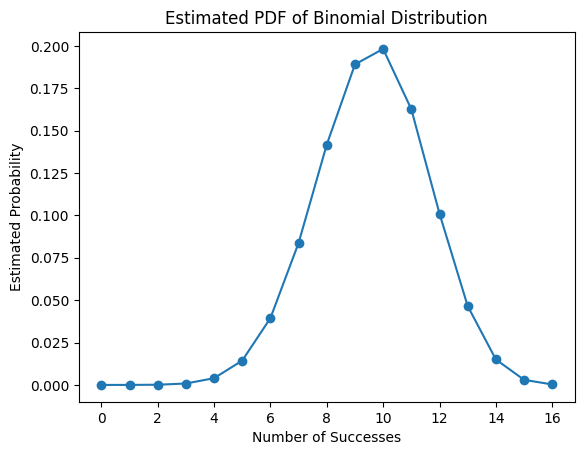

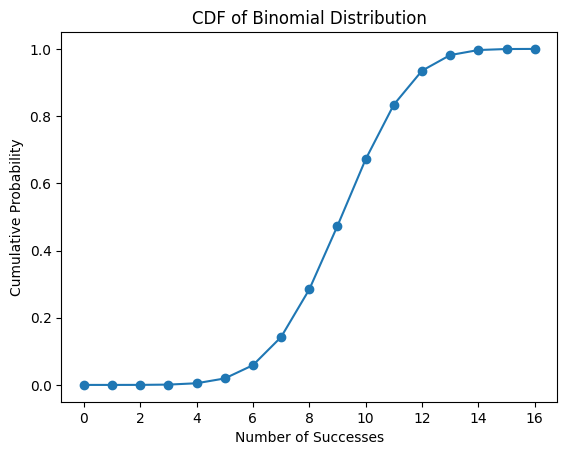

In [15]:
# Estimate PDF using counts
pdf = []
values = list(range(17))  # possible outcomes: 0 through 16

for i in values:
    count = np.sum(data == i)
    pdf.append(count / 1000000)

# Plot estimated PDF
plt.plot(values, pdf, marker='o')

plt.xlabel("Number of Successes")
plt.ylabel("Estimated Probability")
plt.title("Estimated PDF of Binomial Distribution")

plt.show()


# Compute CDF
cdf = np.cumsum(pdf)

# Plot CDF
plt.plot(values, cdf, marker='o')

plt.xlabel("Number of Successes")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Binomial Distribution")

plt.show()

# Problem 4: Poisson Distribution

>a. Figure out the syntax for generating poisson random variables. Simulate 1,000,000 draws from a poisson random variables with lambda=4. Plot the histogram (include labels).

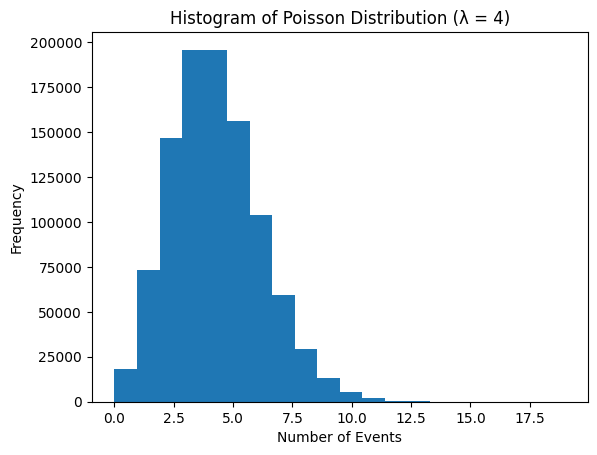

In [16]:
# Generate 1,000,000 draws from a Poisson distribution with lambda = 4
data = np.random.poisson(lam=4, size=1000000)

# Plot histogram
plt.hist(data, bins=20)

plt.xlabel("Number of Events")
plt.ylabel("Frequency")
plt.title("Histogram of Poisson Distribution (λ = 4)")

plt.show()

>b. Calculate the mean and variance of this data and print it out. Print out a sentence description what it should be close to according to what we learned in class about the mean and variance of a poisson distribution.

In [17]:
# Calculate mean and variance
mean_val = np.mean(data)
var_val = np.var(data)

print("Mean:", mean_val)
print("Variance:", var_val)

print("For a Poisson distribution, both the mean and variance should be approximately equal to λ = 4.")

Mean: 3.99855
Variance: 3.9930638974999986
For a Poisson distribution, both the mean and variance should be approximately equal to λ = 4.


>c.	Probabilities of cell attachment can be well modeled by a Poisson distribution. The average number of cells that attached in the first 6 wells after 10 hrs is 10 cells. What is the probability of getting exactly 7 cells attached in the 7th well? You will need to figure out how to generate an exponential and a factorial, which can be found in the math library.


In [18]:
lambda_val = 10
k = 7

# Calculate probability using Poisson formula
prob = (math.exp(-lambda_val) * lambda_val**k) / math.factorial(k)

print("Probability of exactly 7 cells attaching:", prob)

Probability of exactly 7 cells attaching: 0.09007922571921599


# Problem 5: Predicting based on Binomial and Poisson Distributions

> a. On a remote Pacific Island, it is known that 6% of the people have high blood pressure. You measure blood pressure from 100 people. Using the pdf equations we learned in class, calculate the probability of seeing exactly 5 people with high blood pressure in this same population using BOTH a binomial distribution and a poisson distribution. You will need to figure out how to calculate n-choose-k in python.

In [19]:
# Parameters
n = 100
p = 0.06
k = 5
lam = n * p  # poisson approximation parameter

# Binomial probability: P(X = k) = C(n,k) p^k (1-p)^(n-k)
binom_prob = math.comb(n, k) * (p**k) * ((1-p)**(n-k))

# Poisson probability: P(X = k) = e^(-lambda) lambda^k / k!
poisson_prob = math.exp(-lam) * (lam**k) / math.factorial(k)

print("Binomial probability of exactly 5:", binom_prob)
print("Poisson probability of exactly 5:", poisson_prob)

Binomial probability of exactly 5: 0.16391750515911374
Poisson probability of exactly 5: 0.16062314104798003


> b. Check that this matches the result you get using the built in function for calculating the pdf of binomial and poisson distributions. Search for how to use the .pmf notation within scipy.stats for each distribution.

In [20]:
from scipy.stats import binom, poisson

print("Built-in binomial pmf:", binom.pmf(k, n, p))
print("Built-in poisson pmf:", poisson.pmf(k, lam))

Built-in binomial pmf: 0.16391750515911468
Built-in poisson pmf: 0.16062314104797995


>c. For each, simulate doing the experiment 10,000 times. The syntax for how to do this is given in the commands below. Check that they match the percentages above. Execute it a few times to note that it doesn't always give you the same answer.

In [24]:
# Simulate 10,000 experiments
binom_sim = np.random.binomial(n=n, p=p, size=10000)
poisson_sim = np.random.poisson(lam=lam, size=10000)

# Estimate probability of exactly 5
binom_sim_prob = np.sum(binom_sim == 5) / 10000
poisson_sim_prob = np.sum(poisson_sim == 5) / 10000

print("Simulated binomial probability of exactly 5:", binom_sim_prob)
print("Simulated poisson probability of exactly 5:", poisson_sim_prob)

Simulated binomial probability of exactly 5: 0.1615
Simulated poisson probability of exactly 5: 0.1506


NOTE: I ran this 3 times and got different answers each time.